# CyberShield Protection Engine

## Threat Detection, Classification and Automated Protection

The protection workflow follows:

Detect → Classify → Assess → Protect → Verify → Log

In [1]:
import os
import joblib
import sqlite3
import pandas as pd
import numpy as np

from datetime import datetime

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Optimized CyberShield Models

In [2]:
detection_model = joblib.load(
    "../models/cybershield_tuned_detection_model.pkl"
)

attack_classifier = joblib.load(
    "../models/cybershield_tuned_attack_classifier.pkl"
)

protection_threshold = joblib.load(
    "../models/protection_threshold.pkl"
)

selected_features = joblib.load(
    "../models/selected_features.pkl"
)

print("Detection model loaded successfully.")
print("Attack classification model loaded successfully.")
print("Protection threshold:", protection_threshold)
print("Selected features:", len(selected_features))

Detection model loaded successfully.
Attack classification model loaded successfully.
Protection threshold: 0.3
Selected features: 15


## Load Traffic Data for Protection Testing

In [3]:
traffic_data = pd.read_csv(
    "../output/engineered_dataset.csv"
)

print("Engineered Traffic Dataset Shape:", traffic_data.shape)
print("Available Columns:", traffic_data.columns.tolist())

Engineered Traffic Dataset Shape: (145222, 17)
Available Columns: ['ackdat', 'synack', 'dload', 'tcprtt', 'dmean', 'rate', 'sbytes', 'dbytes', 'smean', 'dinpkt', 'dur', 'sload', 'sinpkt', 'djit', 'sjit', 'label', 'attack_cat']


## Prepare Input Features

In [4]:
protection_data = traffic_data[selected_features].copy()

print("Selected Features:", len(selected_features))
print("Protection Input Shape:", protection_data.shape)

Selected Features: 15
Protection Input Shape: (145222, 15)


## Verify Protection Model Inputs

In [5]:
missing_features = [
    feature for feature in selected_features
    if feature not in traffic_data.columns
]

if len(missing_features) == 0:
    print("All selected model features are available.")
else:
    print("Missing Features:")
    print(missing_features)

All selected model features are available.


## Threat Detection Using Protection Threshold

In [6]:
attack_probability = detection_model.predict_proba(
    protection_data
)[:, 1]

detection_prediction = (
    attack_probability >= protection_threshold
).astype(int)

print("Protection Threshold:", protection_threshold)
print("Total Traffic Records:", len(protection_data))
print("Potential Attacks Detected:", detection_prediction.sum())
print("Normal Traffic:", len(detection_prediction) - detection_prediction.sum())

Protection Threshold: 0.3
Total Traffic Records: 145222
Potential Attacks Detected: 78904
Normal Traffic: 66318


## Classify Detected Attacks

In [7]:
attack_mask = detection_prediction == 1

detected_attack_data = protection_data.loc[
    attack_mask
].copy()

print("Detected Attack Records:", len(detected_attack_data))

Detected Attack Records: 78904


## Predict Attack Categories

In [8]:
if len(detected_attack_data) > 0:

    attack_type_prediction = attack_classifier.predict(
        detected_attack_data
    )

    print("Attack Classification Completed.")
    print("Classified Attack Records:", len(attack_type_prediction))

else:

    attack_type_prediction = np.array([])

    print("No attacks detected.")

Attack Classification Completed.
Classified Attack Records: 78904


## Convert Attack Predictions to Readable Names

In [9]:
attack_name_mapping = {
    0: "Analysis",
    1: "Backdoor",
    2: "DoS",
    3: "Exploits",
    4: "Fuzzers",
    5: "Generic",
    6: "Reconnaissance",
    7: "Shellcode",
    8: "Worms"
}

if len(attack_type_prediction) > 0:
    detected_attack_names = [
        attack_name_mapping.get(
            int(prediction),
            "Unknown"
        )
        for prediction in attack_type_prediction
    ]
    print("Attack Categories Identified:")
    print(
        pd.Series(
            detected_attack_names
        ).value_counts()
    )

else:
    detected_attack_names = []
    print("No attack categories to classify.")

Attack Categories Identified:
Exploits     30494
Fuzzers      30348
Shellcode     7564
DoS           4625
Generic       2454
Analysis      1808
Worms          962
Backdoor       552
Unknown         97
Name: count, dtype: int64


## Severity Assessment

In [10]:
severity_mapping = {
    "Analysis": "Medium",
    "Backdoor": "Critical",
    "DoS": "High",
    "Exploits": "Critical",
    "Fuzzers": "Medium",
    "Generic": "High",
    "Reconnaissance": "Medium",
    "Shellcode": "Critical",
    "Worms": "Critical",
    "Unknown": "High"
}
detected_severity = [
    severity_mapping.get(
        attack_type,
        "High"
    )
    for attack_type in detected_attack_names
]
severity_counts = pd.Series(
    detected_severity
).value_counts()
print("Threat Severity Distribution:")
print(severity_counts)

Threat Severity Distribution:
Critical    39572
Medium      32156
High         7176
Name: count, dtype: int64


## Protection Policy Definition

In [11]:
protection_policy = {
    "Critical": {
        "action": "ISOLATE",
        "response": "Immediate connection isolation"
    },
    "High": {
        "action": "BLOCK",
        "response": "Block suspicious connection"
    },
    "Medium": {
        "action": "RESTRICT",
        "response": "Restrict and monitor connection"
    }
}

print("Protection Policy:")
for severity, policy in protection_policy.items():
    print(
        severity,
        "→",
        policy["action"],
        "→",
        policy["response"]
    )

Protection Policy:
Critical → ISOLATE → Immediate connection isolation
High → BLOCK → Block suspicious connection
Medium → RESTRICT → Restrict and monitor connection


## Assign Protection Actions

In [12]:
protection_actions = [
    protection_policy[severity]["action"]
    for severity in detected_severity
]

protection_responses = [
    protection_policy[severity]["response"]
    for severity in detected_severity
]

protection_summary = pd.DataFrame({
    "Attack Type": detected_attack_names,
    "Severity": detected_severity,
    "Protection Action": protection_actions,
    "Response": protection_responses
})

print("Protection Actions Assigned:")
print(
    protection_summary["Protection Action"].value_counts()
)

protection_summary.head(10)

Protection Actions Assigned:
Protection Action
ISOLATE     39572
RESTRICT    32156
BLOCK        7176
Name: count, dtype: int64


,Attack Type,Severity,Protection Action,Response
0,DoS,High,BLOCK,Block suspicious connection
1,Exploits,Critical,ISOLATE,Immediate connection isolation
2,Exploits,Critical,ISOLATE,Immediate connection isolation
3,Exploits,Critical,ISOLATE,Immediate connection isolation
4,Fuzzers,Medium,RESTRICT,Restrict and monitor connection
5,Fuzzers,Medium,RESTRICT,Restrict and monitor connection
6,Fuzzers,Medium,RESTRICT,Restrict and monitor connection
7,Exploits,Critical,ISOLATE,Immediate connection isolation
8,Exploits,Critical,ISOLATE,Immediate connection isolation
9,Shellcode,Critical,ISOLATE,Immediate connection isolation


## Execute Protection Actions

In [13]:
def execute_protection(action):
    if action == "ISOLATE":
        return "Connection isolated"
    
    elif action == "BLOCK":
        return "Connection blocked"
    
    elif action == "RESTRICT":
        return "Connection restricted"
    
    else:
        return "No protection action"

executed_actions = [
    execute_protection(action)
    for action in protection_actions
]
print("Protection actions executed successfully.")
print(
    pd.Series(executed_actions).value_counts()
)

Protection actions executed successfully.
Connection isolated      39572
Connection restricted    32156
Connection blocked        7176
Name: count, dtype: int64


## Verify Protection Actions

In [14]:
def verify_protection(action_result):
    if action_result in [
        "Connection isolated",
        "Connection blocked",
        "Connection restricted"
    ]:
        return "Protected"
    
    return "Not Protected"

protection_status = [
    verify_protection(action)
    for action in executed_actions
]
print("Protection Verification:")
print(
    pd.Series(protection_status).value_counts()
)

Protection Verification:
Protected    78904
Name: count, dtype: int64


## Create Protection Incident Records

In [15]:
incident_records = pd.DataFrame({
    "Incident ID": [
        f"INC-{i+1:06d}"
        for i in range(len(detected_attack_names))
    ],
    "Attack Type": detected_attack_names,
    "Severity": detected_severity,
    "Protection Action": protection_actions,
    "Action Result": executed_actions,
    "Protection Status": protection_status,
    "Detection Threshold": protection_threshold,
    "Timestamp": datetime.now().strftime(
        "%Y-%m-%d %H:%M:%S"
    )
})
print("Incident Records Created:", len(incident_records))
incident_records.head(10)

Incident Records Created: 78904


,Incident ID,Attack Type,Severity,Protection Action,Action Result,Protection Status,Detection Threshold,Timestamp
0,INC-000001,DoS,High,BLOCK,Connection blocked,Protected,0.3,2026-08-30 10:33:53
1,INC-000002,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
2,INC-000003,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
3,INC-000004,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
4,INC-000005,Fuzzers,Medium,RESTRICT,Connection restricted,Protected,0.3,2026-08-30 10:33:53
5,INC-000006,Fuzzers,Medium,RESTRICT,Connection restricted,Protected,0.3,2026-08-30 10:33:53
6,INC-000007,Fuzzers,Medium,RESTRICT,Connection restricted,Protected,0.3,2026-08-30 10:33:53
7,INC-000008,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
8,INC-000009,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
9,INC-000010,Shellcode,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53


## Protection Summary

In [16]:
print("CyberShield Protection Summary")
print("--------------------------------")
print(
    "Total Incidents:",
    len(incident_records)
)
print(
    "Protected:",
    (incident_records["Protection Status"] == "Protected").sum()
)
print(
    "Not Protected:",
    (incident_records["Protection Status"] == "Not Protected").sum()
)
print("\nProtection Actions:")
print(
    incident_records["Protection Action"].value_counts()
)
print("\nSeverity Distribution:")
print(
    incident_records["Severity"].value_counts()
)

CyberShield Protection Summary
--------------------------------
Total Incidents: 78904
Protected: 78904
Not Protected: 0

Protection Actions:
Protection Action
ISOLATE     39572
RESTRICT    32156
BLOCK        7176
Name: count, dtype: int64

Severity Distribution:
Severity
Critical    39572
Medium      32156
High         7176
Name: count, dtype: int64


## Protection Effectiveness

In [17]:
total_incidents = len(incident_records)
protected_incidents = (
    incident_records["Protection Status"] == "Protected"
).sum()

protection_rate = (
    protected_incidents / total_incidents
    if total_incidents > 0
    else 0
)
print("Protection Effectiveness")
print("------------------------")
print("Total Incidents:", total_incidents)
print("Protected Incidents:", protected_incidents)
print("Protection Rate:", protection_rate)

Protection Effectiveness
------------------------
Total Incidents: 78904
Protected Incidents: 78904
Protection Rate: 1.0


## Save Protection Incident Records

In [18]:
os.makedirs("../output", exist_ok=True)
incident_records.to_csv(
    "../output/protection_incidents.csv",
    index=False
)
print("Protection incident records saved successfully.")
print("File: ../output/protection_incidents.csv")

Protection incident records saved successfully.
File: ../output/protection_incidents.csv


## Connect to CyberShield Database

In [19]:
database_path = "../database/cybershield.db"
connection = sqlite3.connect(database_path)
cursor = connection.cursor()
print("CyberShield database connected successfully.")

CyberShield database connected successfully.


## Create Protection Incident Table

In [20]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS protection_incidents (
    incident_id TEXT PRIMARY KEY,
    attack_type TEXT,
    severity TEXT,
    protection_action TEXT,
    action_result TEXT,
    protection_status TEXT,
    detection_threshold REAL,
    timestamp TEXT
)
""")
connection.commit()
print("Protection incident table created successfully.")

Protection incident table created successfully.


## Store Protection Incidents

In [21]:
incident_records.to_sql(
    "protection_incidents",
    connection,
    if_exists="replace",
    index=False
)
connection.commit()
print("Protection incidents stored successfully.")
print("Records stored:", len(incident_records))

Protection incidents stored successfully.
Records stored: 78904


## Verify Protection Incident Database

In [22]:
verification_data = pd.read_sql_query(
    """
    SELECT *
    FROM protection_incidents
    LIMIT 10
    """,
    connection
)
print("Stored Protection Incidents:")
verification_data

Stored Protection Incidents:


,Incident ID,Attack Type,Severity,Protection Action,Action Result,Protection Status,Detection Threshold,Timestamp
0,INC-000001,DoS,High,BLOCK,Connection blocked,Protected,0.3,2026-08-30 10:33:53
1,INC-000002,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
2,INC-000003,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
3,INC-000004,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
4,INC-000005,Fuzzers,Medium,RESTRICT,Connection restricted,Protected,0.3,2026-08-30 10:33:53
5,INC-000006,Fuzzers,Medium,RESTRICT,Connection restricted,Protected,0.3,2026-08-30 10:33:53
6,INC-000007,Fuzzers,Medium,RESTRICT,Connection restricted,Protected,0.3,2026-08-30 10:33:53
7,INC-000008,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
8,INC-000009,Exploits,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53
9,INC-000010,Shellcode,Critical,ISOLATE,Connection isolated,Protected,0.3,2026-08-30 10:33:53


## Protection Statistics

In [23]:
database_summary = pd.read_sql_query(
    """
    SELECT
        "Severity",
        "Protection Action",
        "Protection Status",
        COUNT(*) AS incident_count
    FROM protection_incidents
    GROUP BY
        "Severity",
        "Protection Action",
        "Protection Status"
    ORDER BY incident_count DESC
    """,
    connection
)
database_summary

,Severity,Protection Action,Protection Status,incident_count
0,Critical,ISOLATE,Protected,39572
1,Medium,RESTRICT,Protected,32156
2,High,BLOCK,Protected,7176


## Close Database Connection

In [24]:
connection.close()

print("CyberShield database connection closed successfully.")

CyberShield database connection closed successfully.


## Attack Category Distribution

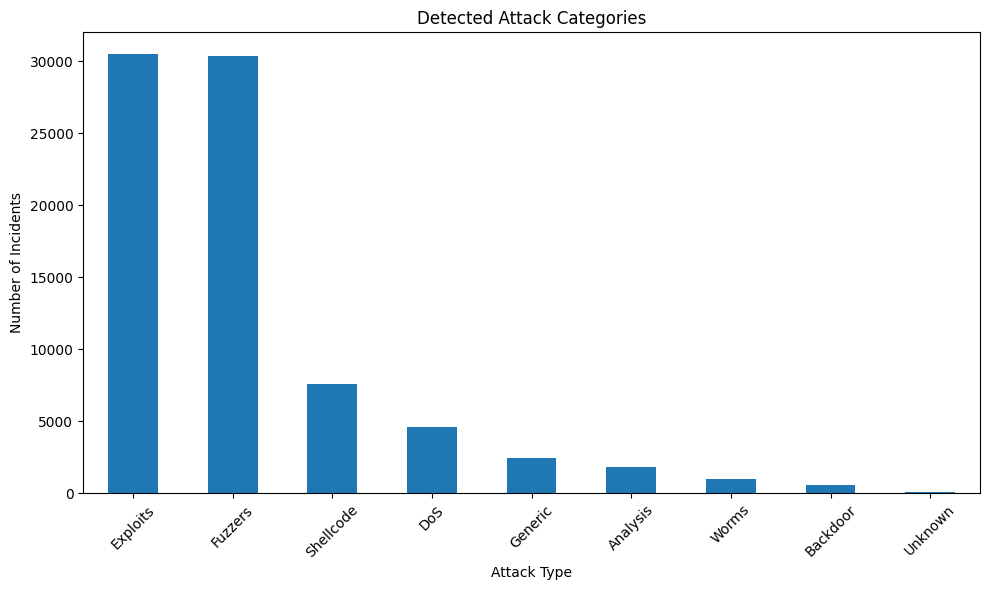

In [25]:
import matplotlib.pyplot as plt
attack_counts = incident_records["Attack Type"].value_counts()
plt.figure(figsize=(10, 6))
attack_counts.plot(kind="bar")
plt.title("Detected Attack Categories")
plt.xlabel("Attack Type")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Threat Severity Distribution

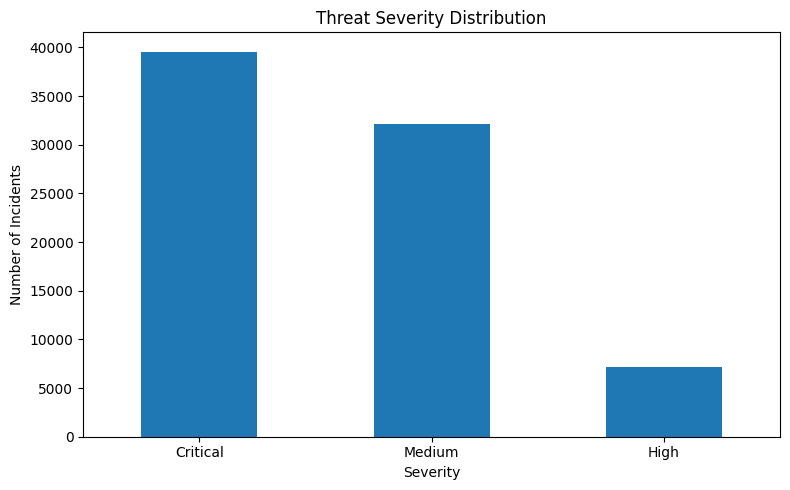

In [26]:
severity_counts = incident_records["Severity"].value_counts()
plt.figure(figsize=(8, 5))
severity_counts.plot(kind="bar")
plt.title("Threat Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Protection Action Distribution

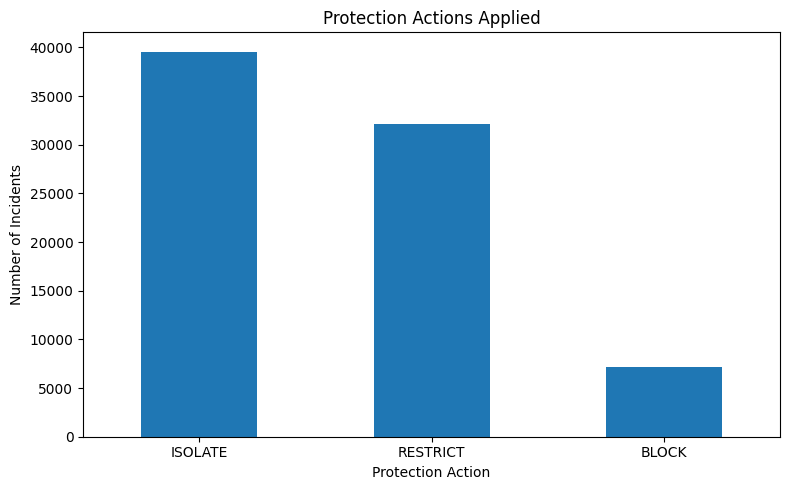

In [27]:
action_counts = incident_records["Protection Action"].value_counts()
plt.figure(figsize=(8, 5))
action_counts.plot(kind="bar")
plt.title("Protection Actions Applied")
plt.xlabel("Protection Action")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Protection Verification Status

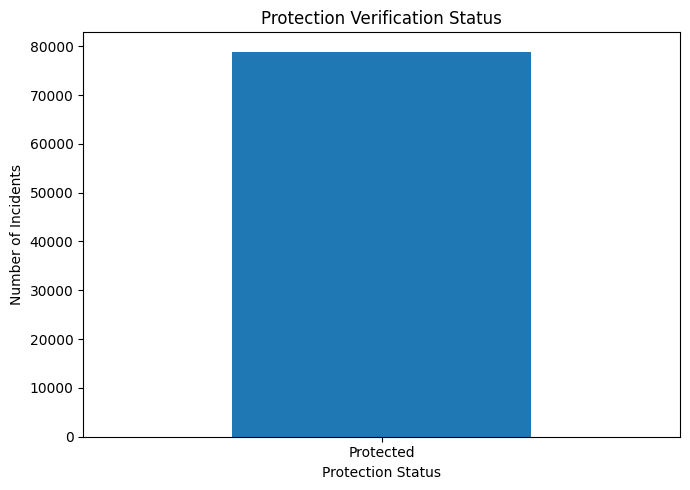

In [28]:
status_counts = incident_records["Protection Status"].value_counts()
plt.figure(figsize=(7, 5))
status_counts.plot(kind="bar")
plt.title("Protection Verification Status")
plt.xlabel("Protection Status")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## CyberShield Protection Engine Final Summary

In [29]:
total_traffic = len(protection_data)
total_attacks = len(incident_records)
total_normal = total_traffic - total_attacks
protected = (
    incident_records["Protection Status"] == "Protected"
).sum()
not_protected = (
    incident_records["Protection Status"] == "Not Protected"
).sum()
print("==============================================")
print("      CYBERSHIELD PROTECTION ENGINE")
print("==============================================")
print("\nTraffic Analysis")
print("----------------")
print("Total Traffic Records :", total_traffic)
print("Normal Traffic        :", total_normal)
print("Attacks Detected      :", total_attacks)
print("\nDetection Configuration")
print("-----------------------")
print("Protection Threshold  :", protection_threshold)
print("\nProtection Actions")
print("------------------")
print("Isolate :", (incident_records["Protection Action"] == "ISOLATE").sum())
print("Block   :", (incident_records["Protection Action"] == "BLOCK").sum())
print("Restrict:", (incident_records["Protection Action"] == "RESTRICT").sum())
print("\nProtection Verification")
print("-----------------------")
print("Protected     :", protected)
print("Not Protected :", not_protected)
if total_attacks > 0:
    verification_rate = protected / total_attacks
else:
    verification_rate = 0
print("Verification Rate :", verification_rate)
print("\n==============================================")
print("Protection Engine completed successfully.")
print("==============================================")

      CYBERSHIELD PROTECTION ENGINE

Traffic Analysis
----------------
Total Traffic Records : 145222
Normal Traffic        : 66318
Attacks Detected      : 78904

Detection Configuration
-----------------------
Protection Threshold  : 0.3

Protection Actions
------------------
Isolate : 39572
Block   : 7176
Restrict: 32156

Protection Verification
-----------------------
Protected     : 78904
Not Protected : 0
Verification Rate : 1.0

Protection Engine completed successfully.
